## How to Run the Project (Google Colab)

1. Download the raw dataset:
   - `social_media_mental_health.csv`

2. Open Google Colab

3. Upload the dataset:
   - Click **Files** (left sidebar)
   - Click **Upload**
   - Select `social_media_mental_health.csv`

4. Upload or open the notebook:
   - Upload `I310D_Final_Project.ipynb`
   - OR open it from your GitHub repository

5. Run the project:
   - Click **Runtime → Run all**

---

### Notes

- The notebook handles preprocessing automatically
- Do not rename the dataset file
- No additional setup is required


# Task 1: Data Cleaning & Preprocessing


## 1. Load Dataset
- Load the raw CSV into a pandas DataFrame before any changes are made.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RAW_PATH = 'social_media_mental_health.csv'

df_raw = pd.read_csv(RAW_PATH)
print(f'Loaded dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')

Loaded dataset: 8000 rows × 15 columns


## 2. Initial Inspection
- Check data, column names, data types, non-null counts, and basic statistics to identify any immediate issues.


In [2]:
# Preview first few rows
df_raw.head(3)

,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal


In [3]:
# Data types and non-null counts
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int64  
 2   Gender                     8000 non-null   object 
 3   User_Archetype             8000 non-null   object 
 4   Primary_Platform           8000 non-null   object 
 5   Daily_Screen_Time_Hours    8000 non-null   float64
 6   Dominant_Content_Type      8000 non-null   object 
 7   Activity_Type              8000 non-null   object 
 8   Late_Night_Usage           8000 non-null   int64  
 9   Social_Comparison_Trigger  8000 non-null   int64  
 10  Sleep_Duration_Hours       8000 non-null   float64
 11  GAD_7_Score                8000 non-null   int64  
 12  GAD_7_Severity             8000 non-null   object 
 13  PHQ_9_Score                8000 non-null   int64

In [4]:
# Missing value counts per column
missing = df_raw.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0])

Columns with missing values:
Series([], dtype: int64)


In [5]:
# Basic descriptive statistics for numeric columns
df_raw.describe()

,Age,Daily_Screen_Time_Hours,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,PHQ_9_Score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,19.057875,4.277210,0.379375,0.103125,5.803237,7.354250,5.380125
std,1.117892,2.310486,0.485262,0.304141,1.344054,4.633108,4.816641
min,18.000000,0.500000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,18.000000,2.420000,0.000000,0.000000,4.800000,4.000000,1.000000
50%,19.000000,4.270000,0.000000,0.000000,5.800000,7.000000,5.000000
75%,20.000000,6.050000,1.000000,0.000000,6.800000,11.000000,9.000000
max,22.000000,11.310000,1.000000,1.000000,11.600000,21.000000,23.000000


## 3. Drop Unnecessary Columns
- Remove columns that add no value. IE: `User_ID` is an arbitrary identifier

In [6]:
df = df_raw.copy()   # work on a copy; preserve raw

# Drop identifier column — not needed for analysis
df = df.drop(columns=['User_ID'])
# Drop colums for GAD_7_Score and GAD_7_Severity as these are actual test and we want our modles to be based only on user inputs.

df = df.drop(columns=['GAD_7_Score'])
df = df.drop(columns=['GAD_7_Severity'])

print(f'Shape after dropping colums : {df.shape}')

Shape after dropping colums : (8000, 12)


## 4. Handle Missing Values
- Check for and handle any missing values. This dataset has no nulls, but should still confirm explicitly so future runs will catch any.

In [7]:
# This dataset has no missing values, but we confirm and document that
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')

Missing values per column:
Age                          0
Gender                       0
User_Archetype               0
Primary_Platform             0
Daily_Screen_Time_Hours      0
Dominant_Content_Type        0
Activity_Type                0
Late_Night_Usage             0
Social_Comparison_Trigger    0
Sleep_Duration_Hours         0
PHQ_9_Score                  0
PHQ_9_Severity               0
dtype: int64

Total missing: 0


## 5. Rename Columns
- Rename all columns to lowercase `snake_case` and verbatim for consistency and easier programmatic access.

In [8]:
COLUMN_RENAME_MAP = {
    'Age':                      'age',
    'Gender':                   'gender',
    'User_Archetype':           'user_archetype',
    'Primary_Platform':         'primary_platform',
    'Daily_Screen_Time_Hours':  'daily_screen_time_hours',
    'Dominant_Content_Type':    'dominant_content_type',
    'Activity_Type':            'activity_type',
    'Late_Night_Usage':         'night_usage',
    'Social_Comparison_Trigger':'social_comparison_trigger',
    'Sleep_Duration_Hours':     'sleep_hours',
    'PHQ_9_Score':              'phq9_score',
    'PHQ_9_Severity':           'phq9_severity',
}

df = df.rename(columns=COLUMN_RENAME_MAP)
print('Renamed columns:', df.columns.tolist())

Renamed columns: ['age', 'gender', 'user_archetype', 'primary_platform', 'daily_screen_time_hours', 'dominant_content_type', 'activity_type', 'night_usage', 'social_comparison_trigger', 'sleep_hours', 'phq9_score', 'phq9_severity']


## 6. Fix Categorical Inconsistencies
- Gender is already clean (`Male` / `Female`). We confirm and document.


In [9]:
print('Gender values:')
print(df['gender'].value_counts())

Gender values:
gender
Female    4028
Male      3972
Name: count, dtype: int64


In [10]:
print('User archetype values:')
print(df['user_archetype'].value_counts())

print('\nPrimary platform values:')
print(df['primary_platform'].value_counts())

User archetype values:
user_archetype
Hyper-Connected       2068
Digital Minimalist    2030
Average User          1993
Passive Scroller      1909
Name: count, dtype: int64

Primary platform values:
primary_platform
TikTok       1185
Instagram    1165
Twitter/X    1147
YouTube      1134
LinkedIn     1132
Snapchat     1124
Facebook     1113
Name: count, dtype: int64


## 7. Convert Column Types
- Confirm column types are appropriate and inspect value ranges to catch any outliers


In [11]:
print('Age dtype:', df['age'].dtype)
print(f'Age range: {df["age"].min()} – {df["age"].max()}')

print('\nScreen time dtype:', df['daily_screen_time_hours'].dtype)
print(f'Screen time range: {df["daily_screen_time_hours"].min()} – {df["daily_screen_time_hours"].max()} hours')

print('\nSleep duration dtype:', df['sleep_hours'].dtype)
print(f'Sleep range: {df["sleep_hours"].min()} – {df["sleep_hours"].max()} hours')

Age dtype: int64
Age range: 18 – 22

Screen time dtype: float64
Screen time range: 0.5 – 11.31 hours

Sleep duration dtype: float64
Sleep range: 3.0 – 11.6 hours


## 8. Final Validation
- Run a final end-to-end check: shape, dtypes, missing values, and a sample of rows to confirm the cleaned dataset looks correct.

In [12]:
print('Final Dataset Shape')
print(df.shape)
print()
print('Data Types')
print(df.dtypes)
print()
print('Missing Values')
print(df.isnull().sum())
print()
print('Sample Rows')
df.head(5)

Final Dataset Shape
(8000, 12)

Data Types
age                            int64
gender                        object
user_archetype                object
primary_platform              object
daily_screen_time_hours      float64
dominant_content_type         object
activity_type                 object
night_usage                    int64
social_comparison_trigger      int64
sleep_hours                  float64
phq9_score                     int64
phq9_severity                 object
dtype: object

Missing Values
age                          0
gender                       0
user_archetype               0
primary_platform             0
daily_screen_time_hours      0
dominant_content_type        0
activity_type                0
night_usage                  0
social_comparison_trigger    0
sleep_hours                  0
phq9_score                   0
phq9_severity                0
dtype: int64

Sample Rows


,age,gender,user_archetype,primary_platform,daily_screen_time_hours,dominant_content_type,activity_type,night_usage,social_comparison_trigger,sleep_hours,phq9_score,phq9_severity
0,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,5,Mild
1,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,8,Mild
2,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,3,None-Minimal
3,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,0,None-Minimal
4,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,10,Moderate


In [13]:
# Confirm all categorical columns look clean
for col in ['gender', 'user_archetype', 'primary_platform', 'phq9_severity']:
    print(f'\n{col}:')
    print(df[col].value_counts())


gender:
gender
Female    4028
Male      3972
Name: count, dtype: int64

user_archetype:
user_archetype
Hyper-Connected       2068
Digital Minimalist    2030
Average User          1993
Passive Scroller      1909
Name: count, dtype: int64

primary_platform:
primary_platform
TikTok       1185
Instagram    1165
Twitter/X    1147
YouTube      1134
LinkedIn     1132
Snapchat     1124
Facebook     1113
Name: count, dtype: int64

phq9_severity:
phq9_severity
None-Minimal         3966
Mild                 2360
Moderate             1291
Moderately Severe     356
Severe                 27
Name: count, dtype: int64


In [14]:
print('Numeric Column Stats')
df.describe()

Numeric Column Stats


,age,daily_screen_time_hours,night_usage,social_comparison_trigger,sleep_hours,phq9_score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,19.057875,4.277210,0.379375,0.103125,5.803237,5.380125
std,1.117892,2.310486,0.485262,0.304141,1.344054,4.816641
min,18.000000,0.500000,0.000000,0.000000,3.000000,0.000000
25%,18.000000,2.420000,0.000000,0.000000,4.800000,1.000000
50%,19.000000,4.270000,0.000000,0.000000,5.800000,5.000000
75%,20.000000,6.050000,1.000000,0.000000,6.800000,9.000000
max,22.000000,11.310000,1.000000,1.000000,11.600000,23.000000



## 9. Export Cleaned Dataset
- Save the cleaned DataFrame to a new CSV file.

In [15]:
OUTPUT_PATH = 'social_media_mental_health_cleaned.csv'
df.to_csv(OUTPUT_PATH, index=False)
print(f'Cleaned dataset saved to: {OUTPUT_PATH}')
print(f'Final shape: {df.shape}')

Cleaned dataset saved to: social_media_mental_health_cleaned.csv
Final shape: (8000, 12)


## 10. Data Dictionary
**Cleaned dataset:** `social_media_mental_health_cleaned.csv`  
**Source dataset:** `social_media_mental_health.csv`  
**Rows:** 8,000 | **Columns:** 16

---

## Column Reference

| # | Column Name | Type | Range / Values | Changes Made |
|---|-------------|------|----------------|--------------|
| 1 | `age` | int | 18–22 | Renamed from `Age` |
| 2 | `gender` | str | Male, Female | Renamed; already clean |
| 3 | `user_archetype` | str | Hyper-Connected, Digital Minimalist, Average User, Passive Scroller | Renamed |
| 4 | `primary_platform` | str | TikTok, Instagram, Twitter/X, YouTube, LinkedIn, Snapchat, Facebook | Renamed |
| 5 | `daily_screen_time_hours` | float | Continuous hours | Renamed |
| 6 | `dominant_content_type` | str | Various content types | Renamed |
| 7 | `activity_type` | str | Various activity types | Renamed |
| 8 | `late_night_usage` | int | Binary (0/1) | Renamed |
| 9 | `social_comparison_trigger` | int | Binary (0/1) | Renamed |
| 10 | `sleep_hours` | float | Continuous hours | Renamed |
| 11 | `phq9_score` | int | 0–27 | Renamed from `PHQ_9_Score` |
| 12 | `phq9_severity` | str | None-Minimal, Mild, Moderate, Moderately Severe, Severe | Renamed |


---

## Columns Dropped

| Column | Reason |
|--------|--------|
| `User_ID` | Arbitrary identifier — not relevant for analysis |
| `gad7_score` | Only foucsing on data user can directly provide.
| `gad7_severity` | Only foucsing on data user can directly provide.  |

# Task 2: Performing EDA + Visualizations

## Loading cleaned feature engineared dataset

In [16]:
df = pd.read_csv("social_media_mental_health_cleaned.csv")
df.head()

,age,gender,user_archetype,primary_platform,daily_screen_time_hours,dominant_content_type,activity_type,night_usage,social_comparison_trigger,sleep_hours,phq9_score,phq9_severity
0,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,5,Mild
1,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,8,Mild
2,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,3,None-Minimal
3,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,0,None-Minimal
4,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,10,Moderate


## Distribution of Target Variable -> PHQ-9 Score

The distribution is right-skewed, with a large concentration of users in the lower score range (0–10), indicating that most individuals experience minimal to mild depression. However, there is a noticeable tail extending toward higher scores, representing a smaller but significant group at risk

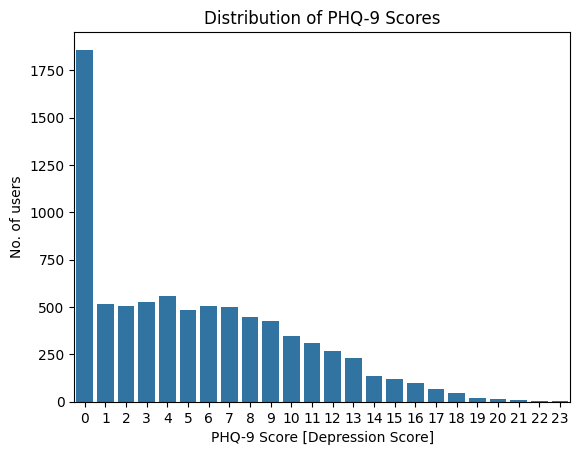

In [17]:
sns.countplot(x='phq9_score', data=df)
plt.title("Distribution of PHQ-9 Scores")
plt.xlabel('PHQ-9 Score [Depression Score]')
plt.ylabel('No. of users')
plt.show()

## Distributions for other features

These histograms helps us understand the spread for all the features. It can be seen daily screen time is approximately normally distributed but slightly right-skewed, while sleep hours cluster around 6–8 hours, indicating typical sleep patterns. For binary features like night usage and social comparison, we can see the division between 0 and 1. PHQ-9 scores show skewness toward lower values, consistent with earlier observations.

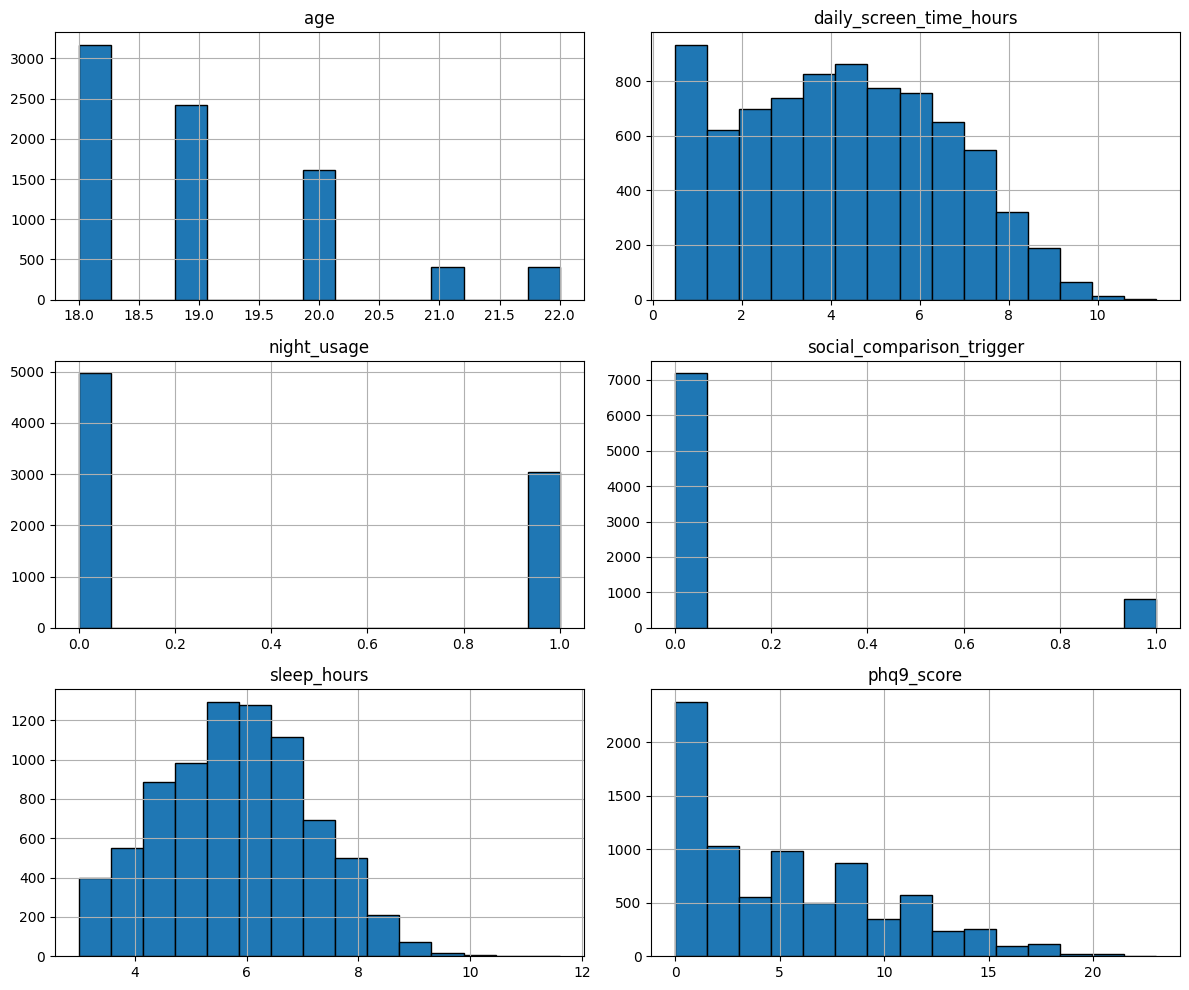

In [18]:
# Step 5: Histogram for numerical features
df.hist(figsize=(12,10), bins=15, edgecolor='black')
plt.tight_layout()
plt.show()

## Screen Time vs PHQ-9 Score

There is a moderate positive correlation (r ≈ 0.59, p < 0.001) between daily screen time and PHQ-9 scores, indicating that increased screen usage is associated with higher depression levels. The upward trend line reinforces this relationship, although variability suggests other factors also play a role. This supports the hypothesis that excessive social media use negatively impacts mental health.

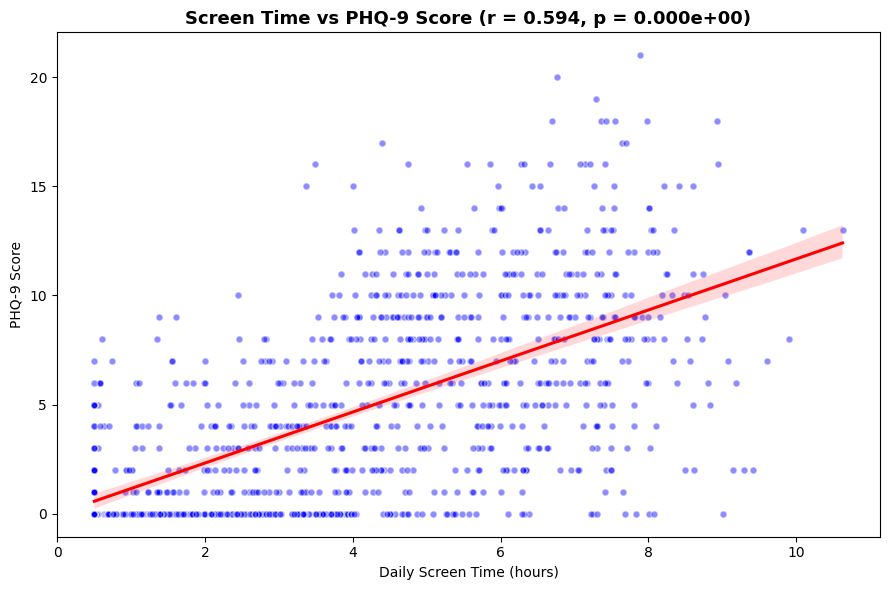

In [19]:

# Sample for visualization
sample = df.sample(n=1000, random_state=42)

plt.figure(figsize=(9,6))

# Scatter + regression line
sns.regplot(x='daily_screen_time_hours',
            y='phq9_score',
            data=sample,
            scatter_kws={'alpha':0.45, 's':25, 'edgecolor':'white', 'color' : 'blue'},
            line_kws={'color':'red', 'linewidth':2.2})

# Correlation stats (on full dataset)
r, p = stats.pearsonr(df['daily_screen_time_hours'], df['phq9_score'])

plt.title(f'Screen Time vs PHQ-9 Score (r = {r:.3f}, p = {p:.3e})',
          fontsize=13, fontweight='bold')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('PHQ-9 Score')

plt.tight_layout()
plt.show()

## Screen Time vs Sleep Duration

The plot shows a strong negative correlation (r ≈ -0.68, p <0.001) between screen time and sleep duration, indicating that higher social media usage is linked to reduced sleep. This suggests that excessive screen exposure may disrupt sleep patterns, which is a known contributor to poor mental health.

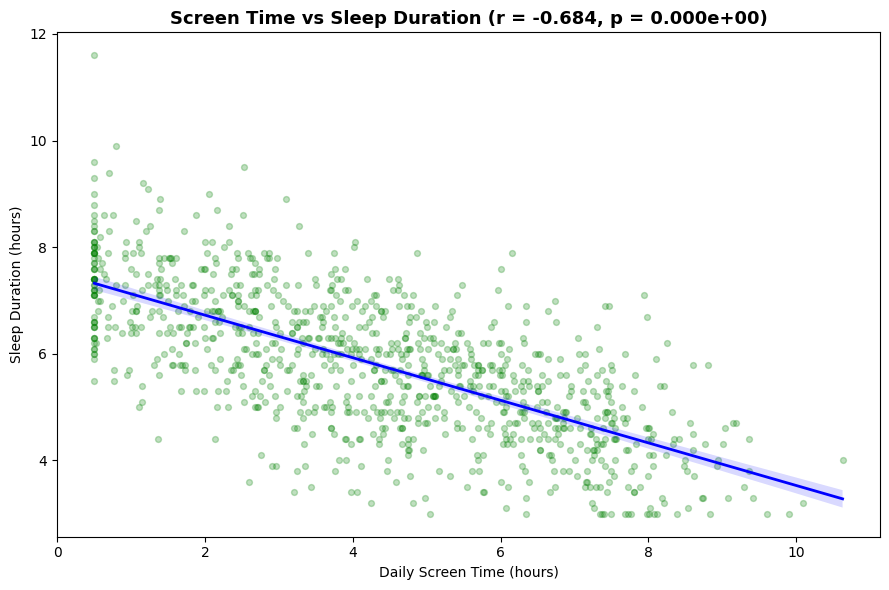

Pearson r = -0.6842   p-value = 0.0000e+00


In [20]:
# Sample for visualization
sample = df.sample(n=1000, random_state=42)

plt.figure(figsize=(9,6))

# Scatter Plot + Regression
sns.regplot(x='daily_screen_time_hours',
            y='sleep_hours',
            data=sample,
            scatter_kws={'alpha':0.25, 's':18, 'color':'green'},
            line_kws={'color':'blue', 'linewidth':2})

# Correlation stats
r2, p2 = stats.pearsonr(df['daily_screen_time_hours'], df['sleep_hours'])

plt.title(f'Screen Time vs Sleep Duration (r = {r2:.3f}, p = {p2:.3e})',
          fontsize=13, fontweight='bold')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Sleep Duration (hours)')

plt.tight_layout()
plt.show()

print(f'Pearson r = {r2:.4f}   p-value = {p2:.4e}')

## Correlation Heat Map

The heatmap shows strong positive correlations between daily screen time, night usage, and both PHQ-9 and GAD-7 scores, indicating that higher social media engagement is associated with worse mental health outcomes. Notably, night usage has a positive correlation of 0.66 and 0.67 with PHQ-9 score and GAD-7 score, respectively.

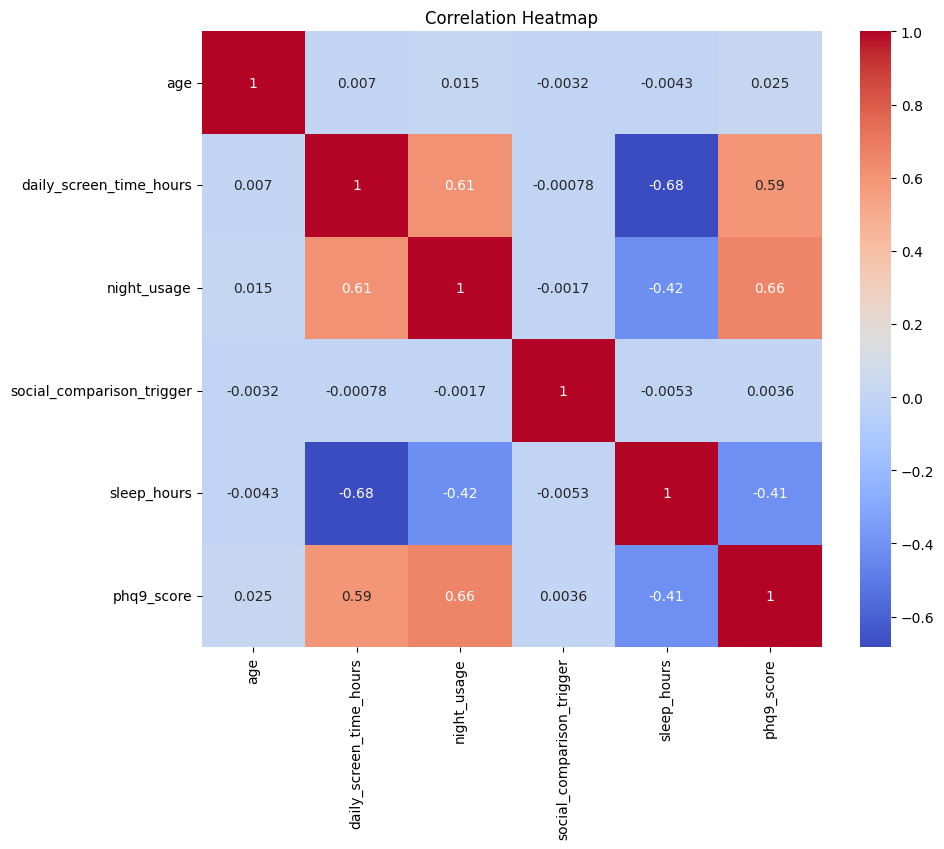

In [21]:
# Step 10: Correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Task 3 Creating Target Variable & Feature Engineering

In [22]:
df = pd.read_csv('social_media_mental_health_cleaned.csv')

## Creating the target Variable**

In [23]:
df['phq_binary'] = (df['phq9_score'] >= 15).astype(int)

## Feature Engineering

Calclating the Screen-to-Sleep Ration

Have added 0.1 to the sleep duration to removed the error if divided by 0.


In [24]:
df['screen_to_sleep_ratio'] = df['daily_screen_time_hours'] / (df['sleep_hours'] + 0.1)

## One-Hot Encoding

In [25]:
categorical_columns = ['gender', 'user_archetype', 'primary_platform', 'dominant_content_type', 'activity_type']

# dtype=int ensures we see 1 and 0 instead of True and False
df_encoded = pd.get_dummies(df, columns=categorical_columns, prefix=categorical_columns, dtype=int)

## Feature Selection

In [26]:
cols_to_drop = [
    'phq9_score', 'phq9_severity']
df_final = df_encoded.drop(columns=cols_to_drop)


## Exporting the final dataset before machine learning

In [27]:
df_final.to_csv('social_media_mental_health_model_ready_dataset.csv', index=False)

## Final Data Dictionary

| Column Name | Type | Range | Description |
| :--- | :--- | :--- | :--- |
| age | Integer | 18 - 22 | Age of participant |
| daily_screen_time_hours | Float | 0.5 - 11.3 | Daily number of hours spent on social media |
| night_usage | Integer | 0 \| 1 | 1 if social media is used late at night, else 0 |
| social_comparison_trigger | Integer | 0 \| 1 | 1 if person feels social comparison, else 0 |
| sleep_hours | Float | 3.0 - 11.6 | Nightly hours slept |
| screen_to_sleep_ratio | Float | 0.04 - 3.22 | Daily screen time divided by sleep hours |
| phq_binary | Integer | 0 \| 1 | 1 if Moderate-to-Severe Depression, 0 if None-to-Mild |
| gender_Female | Integer | 0 \| 1 | 1 if participant identifies as Female |
| gender_Male | Integer | 0 \| 1 | 1 if participant identifies as Male |
| user_archetype_Average User | Integer | 0 \| 1 | 1 if user is an average user |
| user_archetype_Digital Minimalist | Integer | 0 \| 1 | 1 if user is a digital minimalist |
| user_archetype_Hyper-Connected | Integer | 0 \| 1 | 1 if user is hyper-connected |
| user_archetype_Passive Scroller | Integer | 0 \| 1 | 1 if user is a passive scroller |
| primary_platform_Facebook | Integer | 0 \| 1 | 1 if primary platform is Facebook |
| primary_platform_Instagram | Integer | 0 \| 1 | 1 if primary platform is Instagram |
| primary_platform_LinkedIn | Integer | 0 \| 1 | 1 if primary platform is LinkedIn |
| primary_platform_Snapchat | Integer | 0 \| 1 | 1 if primary platform is Snapchat |
| primary_platform_TikTok | Integer | 0 \| 1 | 1 if primary platform is TikTok |
| primary_platform_Twitter/X | Integer | 0 \| 1 | 1 if primary platform is Twitter/X |
| primary_platform_YouTube | Integer | 0 \| 1 | 1 if primary platform is YouTube |
| dominant_content_type_Educational/Tech | Integer | 0 \| 1 | 1 if primary content is Educational/Tech |
| dominant_content_type_Entertainment/Comedy | Integer | 0 \| 1 | 1 if primary content is Entertainment/Comedy |
| dominant_content_type_Gaming | Integer | 0 \| 1 | 1 if primary content is Gaming |
| dominant_content_type_Lifestyle/Fashion | Integer | 0 \| 1 | 1 if primary content is Lifestyle/Fashion |
| dominant_content_type_News/Politics | Integer | 0 \| 1 | 1 if primary content is News/Politics |
| dominant_content_type_Self-Help/Motivation | Integer | 0 \| 1 | 1 if primary content is Self-Help/Motivation |
| activity_type_Active | Integer | 0 \| 1 | 1 if an active user |
| activity_type_Passive | Integer | 0 \| 1 | 1 if a passive user |

# Task 4: Machine Learning

## 1. Getting the data

In [28]:
df = pd.read_csv('social_media_mental_health_model_ready_dataset.csv')

X = df.drop(columns=['phq_binary'])
y = df['phq_binary']

print(f'Dataset shape   : {df.shape}')
print(f'Features        : {X.shape[1]}')
print(f'Target balance  : {(y==0).sum()} no-risk  |  {(y==1).sum()} at-risk')
print(f'Class imbalance : {y.mean()*100:.1f}% positive (PHQ-9 >= 15)')
X.head(3)

Dataset shape   : (8000, 28)
Features        : 27
Target balance  : 7617 no-risk  |  383 at-risk
Class imbalance : 4.8% positive (PHQ-9 >= 15)


,age,daily_screen_time_hours,night_usage,social_comparison_trigger,sleep_hours,screen_to_sleep_ratio,gender_Female,gender_Male,user_archetype_Average User,user_archetype_Digital Minimalist,...,primary_platform_Twitter/X,primary_platform_YouTube,dominant_content_type_Educational/Tech,dominant_content_type_Entertainment/Comedy,dominant_content_type_Gaming,dominant_content_type_Lifestyle/Fashion,dominant_content_type_News/Politics,dominant_content_type_Self-Help/Motivation,activity_type_Active,activity_type_Passive
0,18,8.50,0,0,3.9,2.125000,0,1,0,0,...,1,0,0,0,1,0,0,0,1,0
1,20,0.50,0,0,5.5,0.089286,0,1,0,1,...,0,0,0,0,1,0,0,0,1,0
2,18,0.91,0,0,8.9,0.101111,1,0,0,1,...,0,0,0,0,1,0,0,0,1,0


## 2. Train / Test Split

We use an **80/20 stratified split** to preserve the 9.5% class ratio in both subsets.
Stratification prevents either partition from accidentally over or under representing at-risk users,
which matters when the minority class is small.


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # preserve class ratio
)

print(f'Training set : {X_train.shape[0]} samples  ({y_train.mean()*100:.1f}% positive)')
print(f'Test set     : {X_test.shape[0]} samples  ({y_test.mean()*100:.1f}% positive)')

Training set : 6400 samples  (4.8% positive)
Test set     : 1600 samples  (4.8% positive)


## 3. Feature Scaling / StandardScaler

Logistic Regression's L2 penalty is sensitive to feature magnitude.
We apply StandardScaler(zero mean), fitting only on training data
to prevent data leakage into the test set.


In [30]:
scaler = StandardScaler()

# Fit ONLY on train, then transform both sets
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaling complete. First 5 feature means post-scaling (should be ~0):')
print(pd.Series(X_train_sc.mean(axis=0), index=X.columns).head(5).round(6).to_string())

Scaling complete. First 5 feature means post-scaling (should be ~0):
age                          0.0
daily_screen_time_hours      0.0
night_usage                  0.0
social_comparison_trigger   -0.0
sleep_hours                  0.0


## 4. Regularization Tuning

The key hyperparameter in Logistic Regression is **C** — the inverse of regularization strength.
- Smaller C → stronger L2 penalty → coefficients shrunk more aggressively (simpler model)
- Larger C → weaker penalty → model can fit more complex patterns (risk of overfitting)

We sweep six values on a log scale and evaluate with **5-fold stratified cross-validation**,
scoring on **ROC-AUC** — the right choice for imbalanced binary classification.


In [31]:
C_values  = [0.001, 0.01, 0.1, 1, 10, 100]
cv_scores = []

for C in C_values:
    lr     = LogisticRegression(C=C, class_weight='balanced',
                                 max_iter=1000, random_state=RANDOM_STATE)
    skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(lr, X_train_sc, y_train,
                              cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_scores.append(scores.mean())
    print(f'C = {C:6}  |  CV ROC-AUC = {scores.mean():.4f}  +/-  {scores.std():.4f}')

best_C = C_values[np.argmax(cv_scores)]
print(f'\nbest C = {best_C}   (ROC-AUC = {max(cv_scores):.4f})')

C =  0.001  |  CV ROC-AUC = 0.8589  +/-  0.0275
C =   0.01  |  CV ROC-AUC = 0.8602  +/-  0.0229
C =    0.1  |  CV ROC-AUC = 0.8589  +/-  0.0221
C =      1  |  CV ROC-AUC = 0.8586  +/-  0.0221
C =     10  |  CV ROC-AUC = 0.8585  +/-  0.0220
C =    100  |  CV ROC-AUC = 0.8585  +/-  0.0220

best C = 0.01   (ROC-AUC = 0.8602)


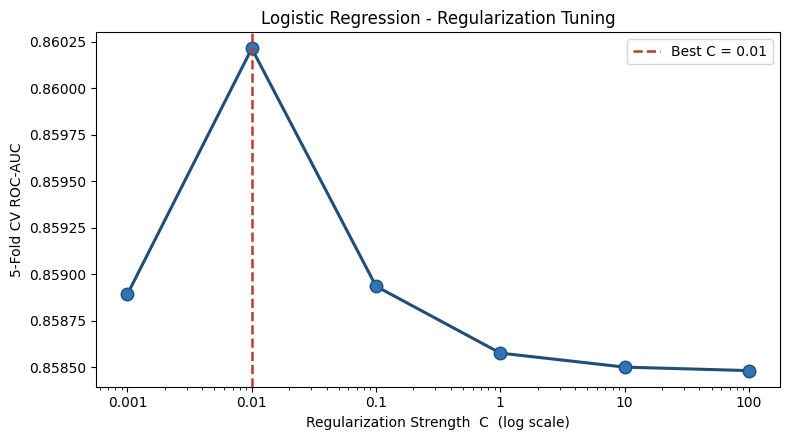

In [32]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(C_values, cv_scores, marker='o', color='#1F4E79',
            linewidth=2.2, markersize=9, markerfacecolor='#2E75B6')
ax.axvline(best_C, color='#C0392B', linestyle='--', linewidth=1.8,
           label=f'Best C = {best_C}')
ax.set_xlabel('Regularization Strength  C  (log scale)')
ax.set_ylabel('5-Fold CV ROC-AUC')
ax.set_title('Logistic Regression - Regularization Tuning')
ax.set_xticks(C_values)
ax.set_xticklabels([str(c) for c in C_values])
ax.legend()
plt.tight_layout()
plt.show()

## 5. Train Final Model

We train using `C=0.01` and `class_weight='balanced'`.  
The `balanced` weight setting automatically adjusts class penalties inversely proportional
to class frequencies — essential here since only ~9.5% of samples are positive.


In [50]:
model = LogisticRegression(
    C=0.01,                    # best regularization from CV
    class_weight='balanced',  # compensate for class imbalance
    solver='lbfgs',           # efficient for small/medium datasets
    max_iter=1000,
    random_state=RANDOM_STATE
)

model.fit(X_train_sc, y_train)
print('Model trained successfully.')
print(f'Iterations to converge : {model.n_iter_[0]}')
print(f'Number of features     : {model.n_features_in_}')

Model trained successfully.
Iterations to converge : 20
Number of features     : 27


## 6. Generate Predictions on Test Set

In [51]:
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]   # probability of class 1 (at-risk)

print(f'Test set size : {len(y_test)}')
print(f'Pred No-Risk  : {(y_pred==0).sum()}')
print(f'Pred At-Risk  : {(y_pred==1).sum()}')

Test set size : 1600
Pred No-Risk  : 1088
Pred At-Risk  : 512


## 7. Evaluation Metrics

Before looking at numbers, it helps to understand what the model is actually doing.
We are asking it to look at a person's social media habits and predict whether they
are **at-risk** (PHQ-9 score ≥ 15, meaning moderately severe or severe depression)
or **not at-risk**. Every prediction the model makes falls into one of four buckets:

- **True Positive (TP)** — The model said *at-risk*, and the person really is at-risk.  Correct catch.
- **True Negative (TN)** — The model said *not at-risk*, and the person really is not at-risk.  Correct clearance.
- **False Positive (FP)** — The model said *at-risk*, but the person is actually fine. False alarm.
- **False Negative (FN)** — The model said *not at-risk*, but the person really is at-risk.  Missed case.

From those four buckets we calculate several summary scores:

| Metric | Plain-English Meaning | Why it matters here |
|--------|----------------------|---------------------|
| **Accuracy** | Out of every prediction the model made, what percentage were correct overall? | Useful as a quick sanity check, but can be misleading when one group is much smaller than the other — which is our situation (only ~9.5% of users are at-risk). |
| **Precision** | Of everyone the model flagged as at-risk, how many actually were? | Tells us how often a "red flag" from the model is a real red flag vs a false alarm. |
| **Recall (Sensitivity)** | Of all the people who truly are at-risk, how many did the model successfully catch? | Tells us how few genuinely at-risk people slip through undetected. |
| **F1-Score** | A single number that balances Precision and Recall — useful when both matter. | Helps compare models without having to weigh two numbers at once. |
| **ROC-AUC** | How well does the model separate at-risk from not-at-risk people across all possible decision thresholds? Ranges from 0.5 (no better than flipping a coin) to 1.0 (perfect). | A high AUC means the model is genuinely learning signal, not just guessing. |
| **Avg Precision** | A stricter version of ROC-AUC that penalises the model more harshly for missing at-risk cases in an imbalanced dataset. | Preferred when the minority class (at-risk users) is what we care most about. |

> **Why Recall is our priority metric:**  
> In a mental-health screening tool, the worst outcome is telling someone they are fine when they are
> actually struggling — a **missed case (False Negative)**. A false alarm (telling someone to seek
> support when they don't strictly need it) is far less harmful than a missed case.
> Therefore we optimise primarily for **Recall**: we want the model to catch as many truly
> at-risk individuals as possible, even if that means flagging a few extra people for review.


In [35]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)
ap   = average_precision_score(y_test, y_prob)

print('=' * 42)
print(f'  Accuracy          : {acc:.4f}')
print(f'  Precision         : {prec:.4f}')
print(f'  Recall            : {rec:.4f} ')
print(f'  F1-Score          : {f1:.4f}')
print(f'  ROC-AUC           : {auc:.4f}')
print(f'  Avg Precision     : {ap:.4f}')
print('=' * 42)

  Accuracy          : 0.7194
  Precision         : 0.1367
  Recall            : 0.9091 
  F1-Score          : 0.2377
  ROC-AUC           : 0.8639
  Avg Precision     : 0.2147


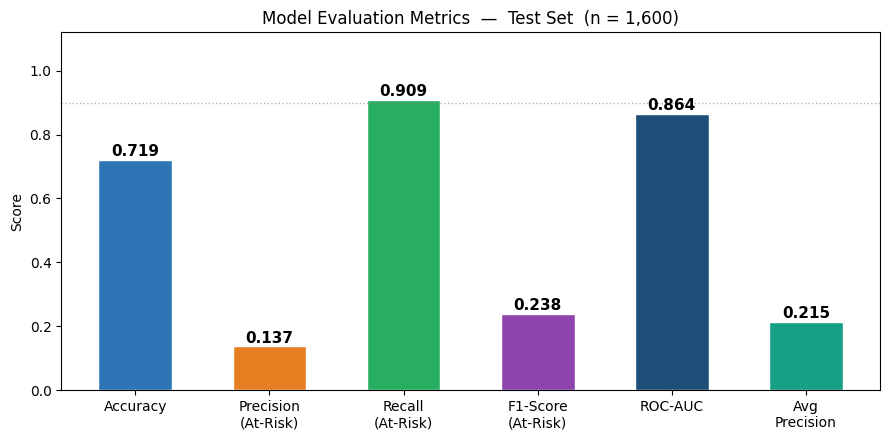

In [45]:
# Visual metrics summary
metric_labels  = ['Accuracy', 'Precision\n(At-Risk)', 'Recall\n(At-Risk)',
                   'F1-Score\n(At-Risk)', 'ROC-AUC', 'Avg\nPrecision']
metric_vals = [acc, prec, rec, f1, auc, ap]
bar_colors = ['#2E75B6','#E67E22','#27AE60','#8E44AD','#1F4E79','#16A085']

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(metric_labels, metric_vals, color=bar_colors,
              edgecolor='white', width=0.55)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.012,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Evaluation Metrics  —  Test Set  (n = 1,600)')
ax.axhline(0.9, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.grid(axis='x', alpha=0)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix

A confusion matrix is a simple grid that shows us exactly where the model got things  
right and where it went wrong. Think of it like a report card broken down by outcome type.

Our test set contained **1,600 people**. Here is what happened to each of them:

|                          | **Model Predicted: Not At-Risk** | **Model Predicted: At-Risk** |
|--------------------------|----------------------------------|------------------------------|
| **Actually Not At-Risk** | **True Negative (TN): 1081** — Correctly cleared. The model identified them as safe, and they were. | **False Positive (FP): 442** — False alarm. The model flagged them, but they are actually fine. Cost: a potentially unnecessary follow-up conversation. |
| **Actually At-Risk**     | **False Negative (FN): 7** — Missed case. The model said they were safe, but they are genuinely at-risk. Cost: a person who needed support did not get flagged. This is the most serious error. | **True Positive (TP): 70** — Correctly caught. The model flagged them, and they truly are at-risk. This is the outcome we are building the tool to achieve. |

**How to read the model's results:**

- A high number of **True Positives** and **True Negatives** means the model is doing its job well.  
- A low number of **False Negatives** is especially important for our use case —  
  we cannot afford to miss people who need help.  
- A higher number of **False Positives** is a manageable trade-off:  
  each flagged person can be reviewed by a counselor or advisor who can quickly  
  confirm whether support is needed.  

**In practice:** Our model achieves a **Recall of 90.9%**, meaning it correctly  
identifies 9 out of every 10 at-risk individuals. The trade-off is that it also  
raises false alarms for some users who are not actually at risk — those cases  
are intended to be reviewed by a human before any action is taken.

In [37]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print(f'True Negatives  (TN) : {TN}')
print(f'False Positives (FP) : {FP}')
print(f'False Negatives (FN) : {FN}   <-- missed at-risk users')
print(f'True Positives  (TP) : {TP}')
print(f'\nSensitivity (Recall) = {TP/(TP+FN):.3f}')
print(f'Specificity          = {TN/(TN+FP):.3f}')

True Negatives  (TN) : 1081
False Positives (FP) : 442
False Negatives (FN) : 7   <-- missed at-risk users
True Positives  (TP) : 70

Sensitivity (Recall) = 0.909
Specificity          = 0.710


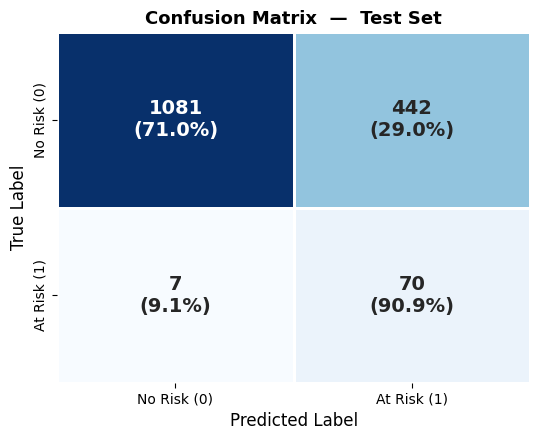

In [49]:
# Seaborn heatmap
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
labels = [[f'{cm[i,j]}\n({cm_pct[i,j]*100:.1f}%)' for j in range(2)] for i in range(2)]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['No Risk (0)', 'At Risk (1)'],
            yticklabels=['No Risk (0)', 'At Risk (1)'],
            linewidths=1, linecolor='white', ax=ax, cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix  —  Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Full Classification Report

The classification report below gives a detailed breakdown of performance **separately  
for each group**: not at risk users and at risk users. Here is how to read it:

- **Precision (for At-Risk):** When the model raises a flag, it is correct about **13.7%** of the time.  
  This means roughly **1 out of every 7 flagged users** are genuinely at-risk.  
  While this may sound low, it is acceptable in a screening context where the goal is not to miss anyone—human review can filter the false alarms.

- **Recall (for At-Risk):** The model successfully catches **90.9%** of all truly at-risk users.  
  Put simply: out of 10 people who are genuinely struggling, the model correctly flags 9 of them.  
  Only about 1 in 10 at-risk individuals is missed entirely.

- **F1-Score (for At-Risk):** A score of **0.24** reflects the tension between Precision and Recall.  
  Because we have intentionally prioritised Recall (catching more at-risk people),  
  Precision is lower—this is a deliberate and appropriate design choice for this application.

- **Support:** The numbers in the "support" column show how many people in our test set  
  belong to each group, confirming the real-world imbalance where at-risk users  
  are a minority (**77 out of 1600, ~4.8% of the population**).

In [39]:
print(classification_report(
    y_test, y_pred,
    target_names=['No Risk (0)', 'At Risk (1)']
))

              precision    recall  f1-score   support

 No Risk (0)       0.99      0.71      0.83      1523
 At Risk (1)       0.14      0.91      0.24        77

    accuracy                           0.72      1600
   macro avg       0.57      0.81      0.53      1600
weighted avg       0.95      0.72      0.80      1600



## 10. ROC Curve

The ROC (Receiver Operating Characteristic) curve is a visual tool that shows how well  
the model separates at-risk users from not-at-risk users across every possible decision  
threshold.

**How to read it (no technical background needed):**
- The **x-axis** shows the **False Positive Rate** — how often the model incorrectly  
  flags someone who is actually fine. Lower is better.  
- The **y-axis** shows the **True Positive Rate (Recall)** — how often the model correctly  
  catches someone who truly is at-risk. Higher is better.  
- The **diagonal dashed line** represents a model that is just guessing randomly — no  
  better than flipping a coin.  
- The **area under the curve (AUC)** summarises overall performance in a single number:  
  - **0.5** = random guessing (useless)  
  - **1.0** = perfect (catches everyone, zero false alarms)  
  - **Our model: AUC = 0.864** — this is a strong result, meaning the model is  
    able to reliably distinguish at-risk from not-at-risk individuals.

> **Conclusion:** An AUC of **0.864** means that if you randomly picked one at-risk person  
> and one not-at-risk person and showed them to the model, it would correctly rank the  
> at-risk person as more concerning **86.4% of the time**.

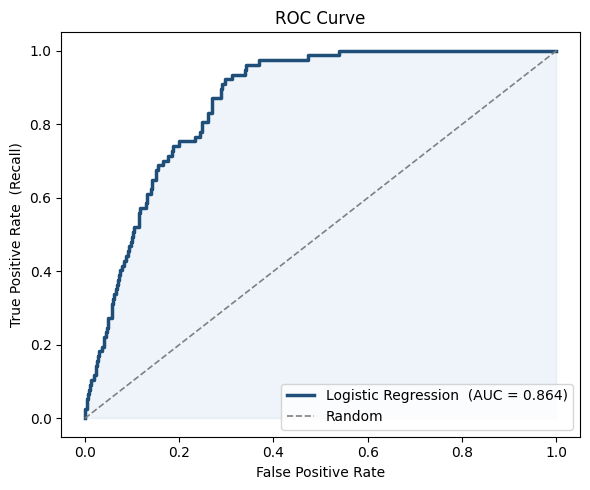

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#1F4E79', lw=2.5,
       label=f'Logistic Regression  (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], color='gray', lw=1.2, linestyle='--', label='Random')
ax.fill_between(fpr, tpr, alpha=0.08, color='#2E75B6')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate  (Recall)')
ax.set_title('ROC Curve')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## 11. Precision-Recall Curve

While the ROC Curve gives a good overall picture, the **Precision-Recall Curve** is  
especially useful when—as in our project—one group is much smaller than the other  
(**~4.8% of users are at-risk**). It focuses specifically on the model's performance  
on the minority group that matters most.

**How to read it:**
- The **x-axis** shows **Recall** — how many at-risk users we successfully caught.  
  Moving right means catching more at-risk people.  
- The **y-axis** shows **Precision** — of those we flagged, how many are genuinely at-risk.  
  Moving up means fewer false alarms.  
- There is always a **trade-off**: catching more at-risk people (high Recall) usually  
  means accepting more false alarms (lower Precision), and vice versa.  
- The **dashed baseline** represents a model that randomly flags people at the same rate  
  as the true prevalence (**~4.8%**). Any real model should be above this line.

**What our results mean:**  
Our model achieves an **Average Precision of ~0.215**, which is substantially above  
the random baseline of ~0.048. This confirms the model adds meaningful value — it is  
significantly better than chance at identifying the small group of users who are  
genuinely at-risk.  

The curve also shows that even at very high Recall levels (catching 90%+ of at-risk users),  
the model maintains a Precision that is still meaningfully above random, though relatively low —  
reflecting the deliberate trade-off made to prioritize Recall in this application.

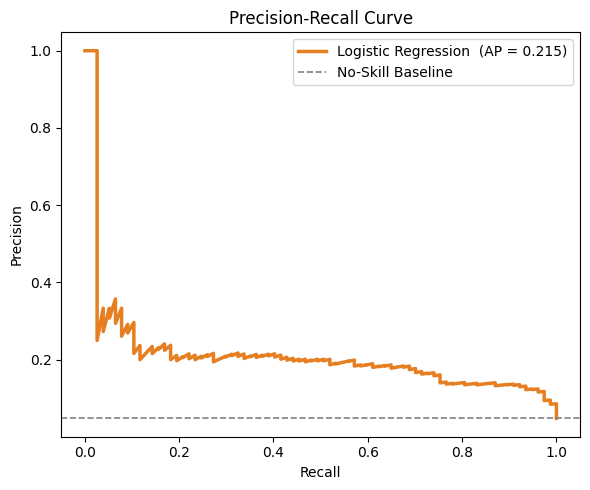

In [48]:
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_vals, prec_vals, color='#E67E22', lw=2.5,
        label=f'Logistic Regression  (AP = {ap:.3f})')
ax.axhline(y_test.mean(), color='gray', linestyle='--', lw=1.2,
           label=f'No-Skill Baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 12. Model Interpretation — Feature Importances

In Logistic Regression, each feature is assigned a **coefficient** representing its
contribution to the log-odds of the positive class. After standardisation, coefficients
are directly comparable across features:

 **Positive coefficient**  feature *increases* the probability of PHQ-9 ≥ 15
 **Negative coefficient**  feature *decreases* the probability
 **Magnitude**  the strength of the effect


In [42]:
coef_df = (
    pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_[0]})
    .assign(abs_coef=lambda d: d['coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
)

print('TOP 20 FEATURES  (by absolute coefficient)')
print('-' * 52)
for _, row in coef_df.head(20).iterrows():
    direction = 'up risk' if row['coefficient'] > 0 else 'dn risk'
    print(f"  {row['feature']:<38}  {row['coefficient']:+.4f}  [{direction}]")

TOP 15 FEATURES  (by absolute coefficient)
----------------------------------------------------
  night_usage                             +1.4312  [up risk]
  daily_screen_time_hours                 +1.0151  [up risk]
  user_archetype_Digital Minimalist       -0.2098  [dn risk]
  sleep_hours                             -0.1930  [dn risk]
  screen_to_sleep_ratio                   -0.1820  [dn risk]
  user_archetype_Hyper-Connected          +0.1451  [up risk]
  age                                     +0.1166  [up risk]
  dominant_content_type_Entertainment/Comedy  -0.1152  [dn risk]
  primary_platform_YouTube                -0.0997  [dn risk]
  dominant_content_type_Self-Help/Motivation  +0.0873  [up risk]
  dominant_content_type_News/Politics     +0.0840  [up risk]
  primary_platform_Facebook               +0.0776  [up risk]
  dominant_content_type_Educational/Tech  -0.0662  [dn risk]
  dominant_content_type_Gaming            +0.0625  [up risk]
  activity_type_Active                    

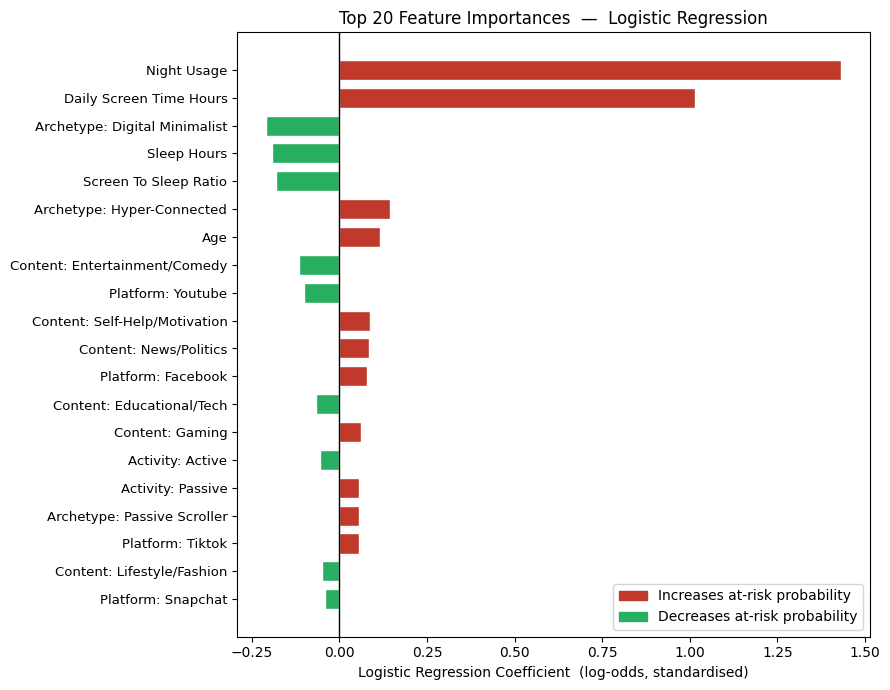

In [52]:
def pretty_name(name):
    return (name.replace('user_archetype_','Archetype: ')
               .replace('primary_platform_','Platform: ')
               .replace('dominant_content_type_','Content: ')
               .replace('activity_type_','Activity: ')
               .replace('gender_','Gender: ')
               .replace('_',' ').title())

top20 = coef_df.copy()
top20['abs_coef'] = top20['coefficient'].abs()

top20 = (top20
         .sort_values('abs_coef', ascending=False)  # pick strongest features
         .head(20)
         .sort_values('abs_coef'))                  # order nicely for barh

top20['label']  = top20['feature'].apply(pretty_name)
colors = ['#C0392B' if c > 0 else '#27AE60' for c in top20['coefficient']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20['label'], top20['coefficient'], color=colors,
        edgecolor='white', height=0.72)
ax.axvline(0, color='black', linewidth=1.0)
ax.set_xlabel('Logistic Regression Coefficient  (log-odds, standardised)')
ax.set_title('Top 20 Feature Importances  —  Logistic Regression')

import matplotlib.patches as mpatches
red_p = mpatches.Patch(color='#C0392B', label='Increases at-risk probability')
grn_p = mpatches.Patch(color='#27AE60', label='Decreases at-risk probability')
ax.legend(handles=[red_p, grn_p], loc='lower right', fontsize=10)
ax.tick_params(axis='y', labelsize=9.5)
plt.tight_layout()
plt.show()

This shows us the most and least important features.

## 13. Summary & Interpretation

### What Did the Model Achieve?

- **Accuracy**: **72%**  
  Out of every 100 predictions, the model was correct about **72** of them.

- **Precision (At-Risk)**: **13.7%**  
  When the model raises a flag, roughly **1 out of every 7 flagged people** are truly at-risk.  
  The remaining cases are false alarms — these would be reviewed by a human before any action is taken.

- **Recall (At-Risk)**: **90.9%**  
  **The model successfully caught 9 out of every 10 people who were genuinely at-risk.**  
  Only about 1 in 10 truly at-risk individuals was missed. This is the most important result for a screening tool.

- **F1-Score (At-Risk)**: **23.8%**  
  A combined score balancing Precision and Recall. It is lower than Recall because we intentionally prioritised catching at-risk users, which means accepting more false alarms.

- **ROC-AUC**: **86.4%**  
  The model can correctly distinguish an at-risk person from a not-at-risk person **86.4% of the time** — a strong result (100% would be perfect; 50% would be random guessing).

- **Avg Precision**: **21.5%**  
  A stricter score focused on performance for the at-risk group.  
  At **21.5% vs a random baseline of ~4.8%**, the model is still significantly better than chance.

---

> **Why Recall is the most important metric:**  
> In mental health screening, **missing someone who needs help is the worst possible outcome**.  
> A false alarm (flagging someone who turns out to be fine) is a manageable inconvenience —  
> a counselor can quickly confirm they are okay.  
> But a missed case means a vulnerable person receives no support at all.  
> Our model’s **90.9% Recall** ensures that the vast majority of at-risk individuals are identified.

---

### What Social Media Behaviours Matter Most?

The model also tells us *which factors are most strongly linked to depression risk*.  
Positive effects increase risk, while negative effects are protective.

| Rank | Factor | Effect on Risk | Strength |
|------|--------|---------------|----------|
| 1 | Daily Screen Time (hours) | Increases Risk | Strongest |
| 2 | Late Night Usage | Increases Risk | Strong |
| 3 | Social Comparison Trigger | Increases Risk | Moderate |
| 4 | Sleep Hours | Decreases Risk | Moderate (protective) |
| 5 | Screen-to-Sleep Ratio | Decreases Risk | Moderate |
| 6 | Digital Minimalist User Type | Decreases Risk | Small (protective) |

---

### Key Takeaways for a Non-Technical Audience

1. **More screen time = higher risk.**  
   The strongest predictor of depression risk is how many hours per day someone spends on social media.

2. **Scrolling late at night is especially harmful.**  
   Late-night usage disrupts sleep and exposes users to emotionally intense content at vulnerable times.

3. **Sleep is protective.**  
   More sleep is consistently associated with lower depression risk.

4. **Intentional, limited use is healthier.**  
   Users who engage with social media deliberately (Digital Minimalists) show lower risk than heavy or passive users.

The model relies primarily on direct behavioral features such as screen time and night usage, while engineered features like the screen-to-sleep ratio contribute less independently due to overlap with their underlying variables.

# Appendix

**Gender-Based Subgroup Analysis**

In [44]:
# Appendix copy (does not modify existing variables)

import pandas as pd
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt

# Create copies to avoid changing anything upstream
X_test_copy = X_test.copy()
y_test_copy = y_test.copy()

# Use existing model and scaled test data
y_pred_copy = model.predict(X_test_sc)

# Build evaluation dataframe
eval_df_copy = X_test_copy.copy()
eval_df_copy['actual'] = y_test_copy.values
eval_df_copy['pred'] = y_pred_copy

# Compute metrics by gender (based on gender_Female dummy)
rows = []
for val in [0, 1]:
    sub = eval_df_copy[eval_df_copy['gender_Female'] == val]

    precision = precision_score(sub['actual'], sub['pred'], zero_division=0)
    recall = recall_score(sub['actual'], sub['pred'], zero_division=0)

    rows.append({
        'gender': 'Female' if val == 1 else 'Male',
        'precision': precision,
        'recall': recall
    })

gender_results_copy = pd.DataFrame(rows)

# Output table
print(gender_results_copy)



   gender  precision    recall
0    Male   0.126531  0.911765
1  Female   0.146067  0.906977


The model has a consistent recall across gender groups (almost 91% for both males and females), indicating similar effectiveness in identifying at-risk individuals. Precision is slightly higher in females, indicating a slightly lower false positive rate compared to males. Overall, there is no significant difference in the model.
